## ⚠️ Warning

This is brute force gaussian blue noise. It has a quadratic complexity on N




## 📦 Install

- pip install numpy matplotlib

small N < 10_000 with jax

- CPU only: pip install jax["cpu"]
- GPU: pip install jax

## 📥 Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import jax
import jax.numpy as jnp
from jax import lax

## 🎨 Plot utilities

In [2]:
def plot(points):
    pts = np.array(points)
    N, D = np.prod(pts.shape[:-1]), pts.shape[-1]

    if D == 2:
        pts = pts[..., :2]
    if D >= 3:
        pts = pts[..., :3]
        D = 3
    pts = pts.reshape(-1, D)

    if N > 30_000:
        ## zooming
        zoom = (30_000/N)**(1.0/D)
        pts = pts[
            (pts <= zoom).all(axis=-1)
        ]

    if D == 2:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=0.4,
            color="black",
        )
    else:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            pts[:, 2],
            s=0.4,
            color="black",
        )
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

def integers_in_ball(radius, D):
    """3D integer vectors inside a sphere of given radius."""
    if radius <= 1.9:
        #here we don't need to build the grid, wich is crucial in high dimension
        return np.zeros((0, D), dtype = np.int32) if radius <= 0.9 else np.eye(D, dtype=np.int32)
    r = np.arange(-radius, radius + 1)
    xyz = np.stack(
        np.meshgrid(*(r,) * D, indexing="ij"), axis=-1
    ).reshape(-1, D)
    xyz_len = np.sum(xyz ** 2, axis=-1)
    return xyz[(xyz_len > 0) & (xyz_len <= radius ** 2)]

def structure_factor(
    points,
    bins = 100,
    resolution=1,
):
    """ structure factor estimated through scattering intensity """
    pts = np.asarray(points)
    N, D = pts.shape

    kmed = int(1000**(1/D))
    kmax = int(2 * N**(1.0/D))

    bins = np.linspace(0, kmax, bins)
    n_bins = len(bins) - 1

    nvecs = np.random.randint(
        -kmax,
        kmax + 1,
        size=(int(resolution*1000), D),
    )

    nvecs = np.concatenate(
        [nvecs, integers_in_ball(kmed, D)],
        axis=0,
    )

    nvecs = nvecs[np.any(nvecs != 0, axis=1)]

    knorm = np.linalg.norm(nvecs, axis=1)

    bin_idx = np.searchsorted(bins, knorm) - 1

    valid = (bin_idx >= 0) & (bin_idx < n_bins)
    nvecs   = nvecs[valid]
    bin_idx = bin_idx[valid]

    kvecs = 2.0 * np.pi * nvecs

    pts   = jnp.array(pts)
    kvecs = jnp.array(kvecs)

    def compute_Sk(k):
        rho = jnp.sum(jnp.exp(1j * (pts @ k)), axis=0)
        return jnp.abs(rho) ** 2 / N

    Sk = jax.lax.map(compute_Sk, kvecs)

    Sk = np.asarray(Sk)

    S = np.bincount(bin_idx, weights=Sk, minlength=n_bins)
    C = np.bincount(bin_idx,             minlength=n_bins)

    valid = C > 0
    S = S[valid] / C[valid]
    k = (0.5 * (bins[:-1] + bins[1:]))[valid]

    return k, S


def plot_sf(x, bins = 100, resolution = 1):
    x = x.reshape(-1, x.shape[-1])

    ks, vals = structure_factor(x)

    plt.figure()
    plt.loglog(ks, vals, marker="o", markersize=2, linewidth=1)
    plt.xlabel("k"); plt.ylabel("S(k)")
    plt.title("Structure factor (log-log)")
    plt.grid(True, which="both"); plt.tight_layout(); plt.show()

## 🏭 Optimizaton pipeline

In [3]:
def _make_hyperparams(N, D):
    """Shared hyperparameter logic."""
    DX = 1 / N ** (1.0 / D)
    S = 1
    sigma2 = S * 2 * DX ** 2
    high_dimension_regime = sigma2 >= 0.03

    if D <= 2:   lr = 0.4
    elif D == 3: lr = 0.1
    elif D == 4: lr = 0.05
    elif D == 5: lr = 0.02
    else:        lr = 0.01

    Niter = 10_000 if not high_dimension_regime else 1_000

    a_ = 2.0 * jnp.pi
    b_ = 2.0 / (sigma2 * a_ ** 2)
    c_ = 1.0 / (2 * S * jnp.pi)

    return sigma2, lr, Niter, high_dimension_regime, a_, b_, c_


def _make_kernels(sigma2, high_dimension_regime, a_, b_, c_):
    """Build pacman + both kernels, return the selected one."""

    def pacman(x):
        return x - jnp.floor(x)

    def gaussian_kernel(x, y):
        delta = pacman(y - x + 0.5) - 0.5
        dist2 = jnp.sum(delta**2, axis = -1, keepdims = True)
        return delta * jnp.exp(-dist2 / sigma2)

    def gaussian_sinus_kernel(x, y):
        delta = a_ * (y - x)
        cos_term = b_ * (1.0 - jnp.cos(delta))
        sin_term = c_ * jnp.sin(delta)
        dist2 = jnp.sum(cos_term, axis = -1, keepdims = True)
        return sin_term * jnp.exp(-dist2)

    print("available kernels [gaussian / gaussian_sine]")

    if high_dimension_regime:
        print(f"selected [gaussian_sine] as sigma2={sigma2:.3f} >= 0.03")
        return pacman, gaussian_sinus_kernel
    else:
        print(f"selected [gaussian] as sigma2={sigma2:.3f} < 0.03")
        return pacman, gaussian_kernel


# ───────────────────
# gradient descent
# ───────────────────
def make_pipeline(N, D):
    sigma2, lr, Niter, high_dim, a_, b_, c_ = _make_hyperparams(N, D)
    pacman, kernel = _make_kernels(sigma2, high_dim, a_, b_, c_)

    def grad(x):
        return kernel(x[:, None], x[None, :]).sum(axis=1)

    @jax.jit
    def run_n_steps(x):
        def step(i, x):
            return pacman(x - lr * grad(x))
        return jax.lax.fori_loop(0, Niter, step, x)

    print("Compiling pipeline...")
    compiled_run = run_n_steps.lower(
        jax.ShapeDtypeStruct((N, D), jnp.float32)
    ).compile()
    print("Done. Pipeline ready.")

    def sample(init=None):
        """Sample a stealthy point pattern. Best for N ≤ 3000."""
        if init is None:
            init = np.random.rand(N, D)
        init = jnp.asarray(init)
        result = compiled_run(init)
        result.block_until_ready()
        return result

    return sample

## 🏁 Entry point:

- N: number of points \
DON'T go beyond **a few thousand points** because brute_force has quadratic complexity

- D: dimension of the points \
feel free to go **up to dimension 100**

In [4]:
N = 100
D = 4

pipeline = make_pipeline(N, D)

available kernels [gaussian / gaussian_sine]
selected [gaussian_sine] as sigma2=0.045 >= 0.03
Compiling pipeline...
Done. Pipeline ready.


## 🔥 Let's go !

In [5]:
Poisson = np.random.rand(N, D)
start = time.time()
stealthy_points = pipeline(init = Poisson)
end = time.time()
print(f"stealthy points ready (runtime {(end-start):.1f} s)")

stealthy points ready (runtime 0.6 s)


benchmark: D = 4
gaussian sine kernel
1000 iterations

GPU Colab 15 Giga JAX

100 points = 0.01 s \
200 points = 0.01 s \
500 points = 0.02 s \
1000 points = 0.08 s \
2000 points = 0.3 s \
5000 points = 2.5 s \
10_000 points = 12 s \
20_000 points = 50 s \
50_000 points = 350 s \
100_000 points: Jax DEAD out of memory \

GPU Colab 15 Giga KeOps

100 points = 1.5 s \
200 points = 3.3 s \
500 points = 7.2 s \
1000 points = 14 s \
2000 points = 27 s \
5000 points = 66 s \
10_000 points = 256 s \
20_000 points = 770 s \
50_000 points:  = 4500 s \
100_000 points = 18000 s \

## 🖼️ Result

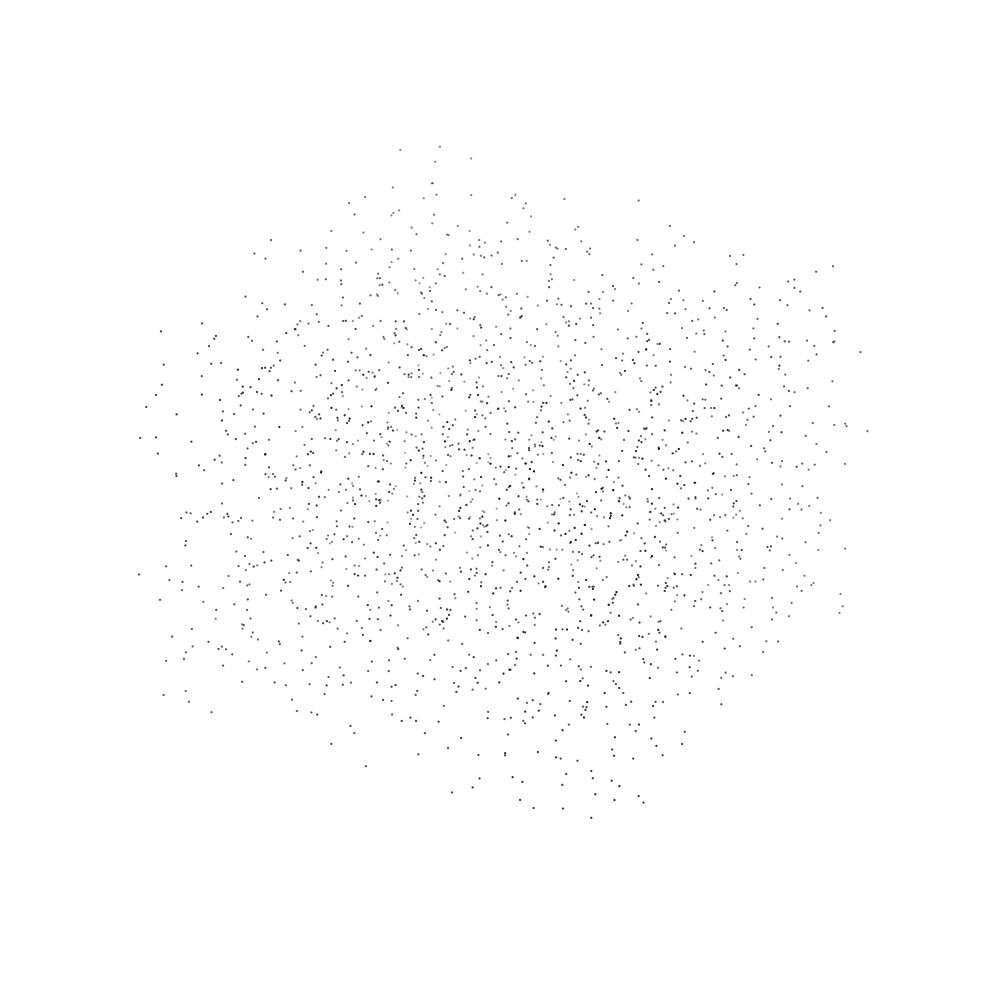

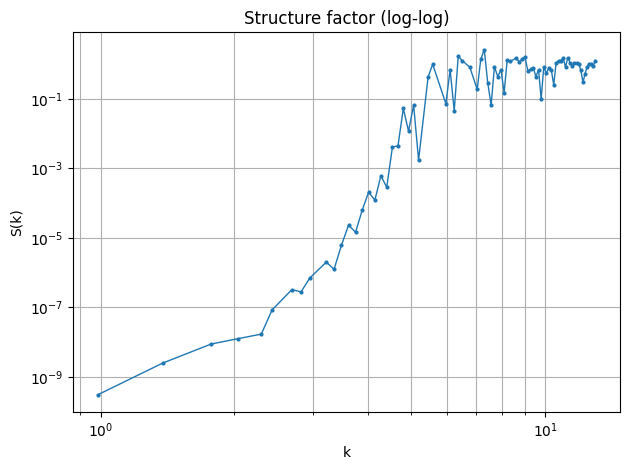

In [6]:
if D <= 4:
    plot(stealthy_points)
plot_sf(stealthy_points, bins = 100, resolution = 1)